# Дослідницька програма для базлайну 91.13% (run_20260630_235356)

Ноутбук відповідає на запити керівника: **(1)** наочний post-mortem помилок 2→7;
**(2)** шість досліджень — інші датасети MNIST, залежність концепту від порядку/кількості/аугментації
навчальних прикладів, кроки редукції до сталого концепту, аналіз параметрів концептів.

**Як користуватися**
- Kernel: **natural-agi** (venv проєкту). Якщо його немає в списку — виконайте один раз у терміналі:
  `.venv/bin/python -m ipykernel install --user --name natural-agi --display-name "natural-agi"`
- Вся логіка — у пакеті `src/training/supervisor_experiments/`; клітинки лише викликають функції та показують результат.
- 🔴 — руйнівні клітинки (зупиняють/чистять Neo4j). Вони виконуються **тільки** якщо ви явно поставите `CONFIRM = "yes"`, і перевіряють наявність бекапу.
- ⚠️ Пастка Jupyter: відредагована клітинка **не** виконується сама — після зміни коду клітинку треба запустити повторно.
- Довгі клітинки друкують час виконання і зберігають артефакти на диск (повторний запуск безпечний).

**Секції:** 0 — налаштування · 1 — post-mortem 2→7 · 2 — параметри концептів (S6) · 3 — збіжність редукції (S5) ·
4 — порядок пред'явлення (S2) · 5 — кількість прикладів (S3) · 6 — датасети MNIST (S1) · 7 — 🔴 ретрени (S3/S4) · 8 — зведення.

In [4]:
import logging, sys
from pathlib import Path

_here = Path.cwd().resolve()
for _c in (_here, *_here.parents):
    if (_c / "src" / "training" / "supervisor_experiments").exists():
        REPO = _c
        sys.path.insert(0, str(_c / "src" / "training"))
        break
else:
    raise RuntimeError("Запустіть Jupyter з кореня репозиторію або з src/training/")

logging.disable(logging.INFO)  # приглушити DEBUG/INFO продукційних модулів
%matplotlib inline

from supervisor_experiments import infra, report
from supervisor_experiments import postmortem as pm

RUN_ID = pm.RUN_ID
print(f"REPO = {REPO}")
print(f"Базлайн: {RUN_ID} (91.13%)")

REPO = /Users/mlapin/Development/personal/NaturalAGI
Базлайн: run_20260630_235356 (91.13%)


### 0.1 Перевірка середовища

Очікування: Neo4j запущений і містить **13 концептів** та **8 685 графів зображень** базлайн-прогону
(`baseline_state_intact: True`). Для Секцій 1–5 достатньо самого Neo4j; Kafka/Nuclio потрібні лише
для Секцій 6–7 (`make start_services` + `docker start $(docker ps -aq --filter name=nuclio-nuclio)`).

In [5]:
health = infra.health_check()
for k, v in health.items():
    print(f"  {k}: {v}")
assert health["neo4j_container_up"], "Neo4j не запущений: docker start naturalagi-neo4j-1"
assert health["baseline_state_intact"], "Стан Neo4j НЕ відповідає базлайну — див. Секцію 7 (відновлення з бекапа)"
print("\n✅ Середовище готове (Tier A)")

  neo4j_container_up: True
  kafka_up: True
  nuclio_functions_up: 26
  concepts: 13
  images: 8685
  baseline_state_intact: True
  backup_exists: False

✅ Середовище готове (Tier A)


### 0.2 🔴 Бекап Neo4j (обов'язковий шлюз перед Секцією 7)

Холодний бекап volume: Neo4j зупиняється на ~1 хв, у `backups/neo4j_baseline_2026-07-17.tar.gz`
зберігається весь стан (концепти + 8 685 графів зображень). Без цього файлу руйнівні клітинки Секції 7 відмовляться працювати.

In [ ]:
CONFIRM = "no
"  # ← поставте "yes", щоб зробити бекап (Neo4j зупиниться на ~1 хв)

if CONFIRM == "yes":
    infra.backup_neo4j(CONFIRM)
else:
    print(f"Бекап існує: {infra.BACKUP_PATH.exists()} ({infra.BACKUP_PATH})")
    print('Щоб створити/оновити: CONFIRM = "yes" і перезапустіть клітинку.')

Бекап існує: False (/Users/mlapin/Development/personal/NaturalAGI/backups/neo4j_baseline_2026-07-17.tar.gz)
Щоб створити/оновити: CONFIRM = "yes" і перезапустіть клітинку.


## Секція 1 — Post-mortem: чому «2» падають у «7»

**Механізм (підтверджено на всіх 111 промахах 2→7):** двоступеневий, зі спільною першопричиною —
втратою якірних точок при побудові графа (ще до редукції):

1. Пре-фільтр складності (`classification_orchestrator.py:97-102`) відкидає концепти зі
   `складність > складність_зображення` **до** порівняння. Збіднений скелет «2» має медіанну складність 21,
   а «повний» концепт 2_2 — 24 → у **77.5%** випадків 2_2 взагалі не бере участі у WTA-конкуренції.
2. Спрощений 2_1 (складність 13) конкурує, але програє 7_1 за сирою схожістю (середній розрив 0.14):
   вцілілі точки стоять «не там» (OUT-of-range за просторовими ознаками).

Кожна клітинка нижче відтворює один крок аналізу продукційним кодом. Підсумковий документ:
[`researches/two_to_seven_postmortem.md`](../../researches/two_to_seven_postmortem.md).

In [7]:
params = pm.load_params()
concepts = pm.load_run_concepts()
confusion = pm.load_confusion(expected="2", predicted="7")
print(f"Концептів у снепшоті прогону: {len(concepts)}")
print(f"Промахів 2→7 у {RUN_ID}: {len(confusion)}")
confusion.head(3)

Концептів у снепшоті прогону: 13
Промахів 2→7 у run_20260630_235356: 111


,status,image_id,image_path,profiling,expected,predicted,correct,error
0,success,7e888443-f097-41e3-984e-75cc46344d5b,/opt/nuclio/shared_storage/mnist_all/2/mnist_t...,"{'skeletonization_time_ms': 33.129042, 'contou...",2,7,False,
1,success,620e1ad6-0b7e-45cb-be71-6566be9a4c3d,/opt/nuclio/shared_storage/mnist_all/2/mnist_t...,"{'skeletonization_time_ms': 77.569667, 'contou...",2,7,False,
2,success,01233b59-f1a4-4cf6-8eb3-6b7d5bf95dbd,/opt/nuclio/shared_storage/mnist_all/2/mnist_t...,"{'skeletonization_time_ms': 44.654167, 'contou...",2,7,False,


**1.1 Як виглядають ці «2»** (перші 12 із 111):

saved researches/figures/two_to_seven/misclassified_2_examples.png


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/figures/two_to_seven/misclassified_2_examples.png')

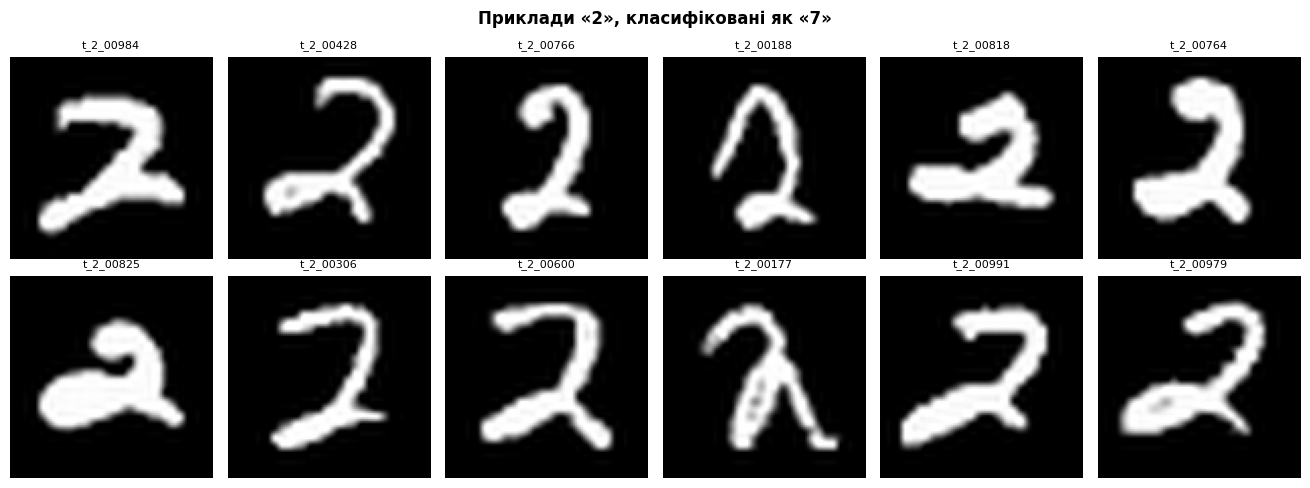

In [8]:
fig = pm.show_images(confusion, n=12)
report.save_figure(fig, "two_to_seven/misclassified_2_examples.png")

**1.2 Продукційний ранкінг еталонного прикладу** — `mnist_test_2_00766` (канонічна «2» із петлею).
Читання виводу: `raw_sim` — сира GED-схожість; `adjusted = raw + 0.10·log₂(складність)`;
концепт **відсутній у списку** ⇔ його зрізав пре-фільтр складності (тут: 2_2 і 8_1).
Нижче — per-feature розбір програшу 2_1 (OUT-of-range ⇒ повний NO_MATCH за Family E).

In [9]:
print(pm.explain_cli(pm.PRIMARY_EXEMPLAR, expected="2"))


=== Ranking (production): raw similarity vs adjusted score (λ=0.1, α=0.0) ===
  concept   raw_sim  adjusted  cx  minor   flag
  7_1        0.8317    1.1487   9   True   PREDICTED
  2_1        0.7300    1.1000  13   True   expected-class
  3_1        0.6491    1.0578  17   True   
  5_1        0.6349    1.0049  13   True   
  1_3        0.6875    0.9197   5   True   
  1_1        0.5211    0.8911  13   True   
  0_1        0.0000    0.0000   0  False   
  4_1        0.0000    0.0000   0  False   
  4_2        0.0000    0.0000   0  False   
  6_1        0.0000    0.0000   0  False   
  9_2        0.0000    0.0000   0  False   
  NOTE: prediction = top by ADJUSTED score. If a correct-class concept has the
        higher raw_sim but lower adjusted, the complexity prior caused the miss.

=== Per-feature substitution costs vs concept 2_1 (GED cost 6.29, sim 0.7300, NO_MATCH=1.0) ===

── SUBSTITUTE [Point|StartPoint]  node_subst_cost = 1.010  (1 OUT-of-range × 1.0 dominate; residual +0.000) 

**1.3 Бакет-аналіз усіх 111 промахів.** Бакети: **A** — жоден 2-концепт не пройшов пре-фільтр;
**B** — конкурував, програв за сирою схожістю; **C** — виграв raw, програв λ-ранжування.
Додатково рахуємо, чи був відфільтрований саме 2_2 (`c22_prefiltered`).

Traceback (most recent call last):
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/concept_minor_classifier.py", line 81, in check_single_concept
    preprocessed_image_graph, preprocessed_concept_graph = self.preprocess_pair(
                                                           ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/concept_minor_classifier.py", line 64, in preprocess_pair
    return self.critical_point_preprocessor.preprocess_graphs(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/services/pre_processing/critical_point_preprocessor.py", line 76, in preprocess_graphs
    inference_graph, concept_graph = self._reduce_graphs_for_isomorphism(
                                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/services/pre_processing/criti

  10/111


Traceback (most recent call last):
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/concept_minor_classifier.py", line 81, in check_single_concept
    preprocessed_image_graph, preprocessed_concept_graph = self.preprocess_pair(
                                                           ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/concept_minor_classifier.py", line 64, in preprocess_pair
    return self.critical_point_preprocessor.preprocess_graphs(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/services/pre_processing/critical_point_preprocessor.py", line 76, in preprocess_graphs
    inference_graph, concept_graph = self._reduce_graphs_for_isomorphism(
                                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/services/pre_processing/criti

  20/111


Traceback (most recent call last):
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/concept_minor_classifier.py", line 81, in check_single_concept
    preprocessed_image_graph, preprocessed_concept_graph = self.preprocess_pair(
                                                           ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/concept_minor_classifier.py", line 64, in preprocess_pair
    return self.critical_point_preprocessor.preprocess_graphs(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/services/pre_processing/critical_point_preprocessor.py", line 76, in preprocess_graphs
    inference_graph, concept_graph = self._reduce_graphs_for_isomorphism(
                                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/services/pre_processing/criti

...

Traceback (most recent call last):
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/concept_minor_classifier.py", line 81, in check_single_concept
    preprocessed_image_graph, preprocessed_concept_graph = self.preprocess_pair(
                                                           ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/concept_minor_classifier.py", line 64, in preprocess_pair
    return self.critical_point_preprocessor.preprocess_graphs(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/services/pre_processing/critical_point_preprocessor.py", line 76, in preprocess_graphs
    inference_graph, concept_graph = self._reduce_graphs_for_isomorphism(
                                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/classification/services/pre_processing/criti

  110/111
[bucket_all over 111 images] elapsed 7.6s


,images,share
bucket,,
B_similarity,111.0,100.0
TOTAL,111.0,100.0


2_2 відфільтровано пре-фільтром: 86/111 (77.5%)
Збіг прогнозу інструмента з прогоном: 111/111
saved researches/figures/two_to_seven/bucket_bar.png


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/figures/two_to_seven/bucket_bar.png')

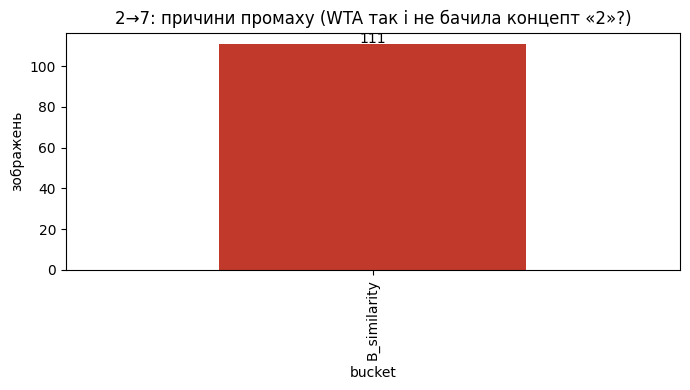

In [10]:
buckets = pm.bucket_all(list(confusion.image_id), concepts, params, expected="2")
buckets = buckets.merge(confusion[["image_id", "image_path"]], on="image_id")
buckets.to_csv(report.FIGURES / "two_to_seven" / "bucket_analysis.csv", index=False)
display(pm.bucket_summary(buckets))
n22 = int(buckets.c22_prefiltered.sum())
print(f"2_2 відфільтровано пре-фільтром: {n22}/{len(buckets)} ({n22/len(buckets)*100:.1f}%)")
print(f"Збіг прогнозу інструмента з прогоном: "
      f"{int((buckets.predicted_tool == '7_1').sum())}/{len(buckets)}")
fig = pm.plot_buckets(buckets)
report.save_figure(fig, "two_to_seven/bucket_bar.png")

**1.4 Триптих для керівника:** зображення → граф до редукції → концепти 2_2 (відфільтровано) і 7_1 (переможець).

saved researches/figures/two_to_seven/mnist_test_2_00766_triptych.png


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/figures/two_to_seven/mnist_test_2_00766_triptych.png')

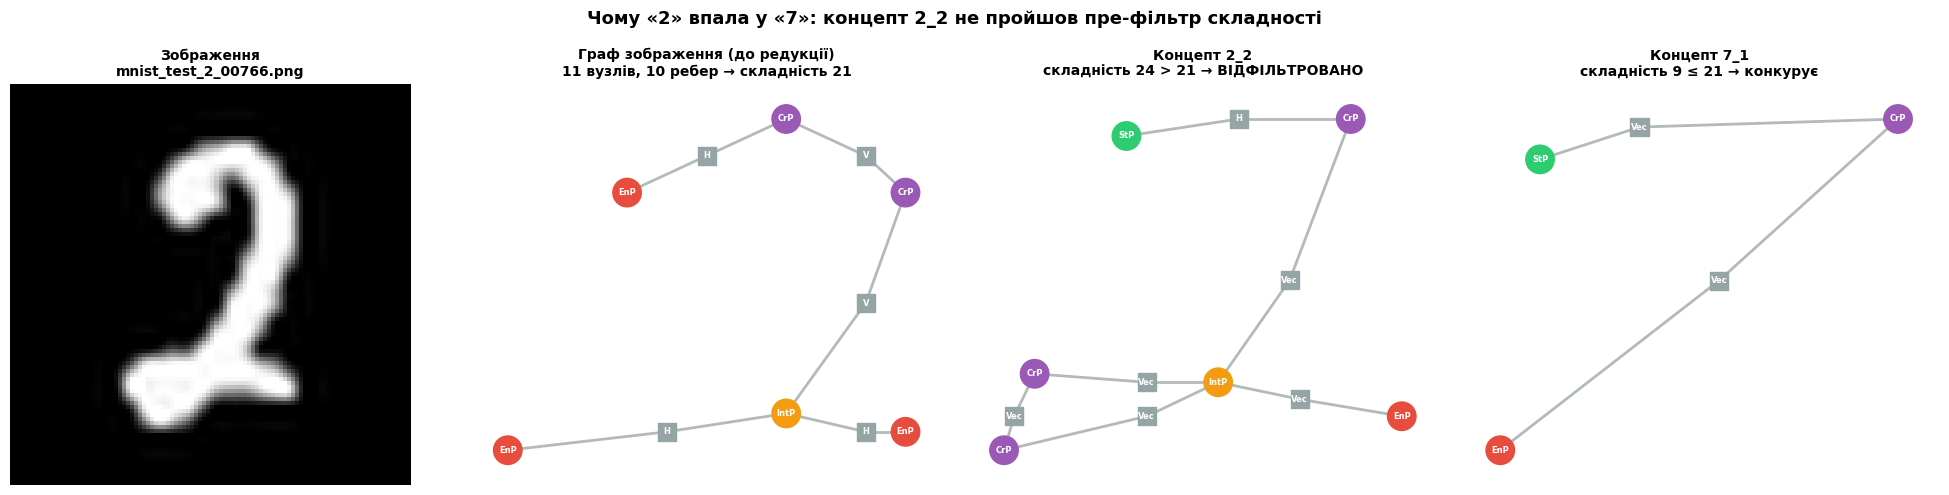

In [11]:
row = confusion[confusion.image_id == pm.PRIMARY_EXEMPLAR].iloc[0]
fig = pm.triptych(pm.PRIMARY_EXEMPLAR, row, concepts, params)
report.save_figure(fig, "two_to_seven/mnist_test_2_00766_triptych.png")

**1.5 Стадії побудови графа** — де саме зникають якірні точки: в оригіналі голова «2» — замкнена петля;
після бінаризації + 1px-thinning вона стає відкритим гачком (0 циклів), GNG+RDP сплющують дугу в 2 сегменти.

/Users/mlapin/Development/personal/NaturalAGI/src/skeletonization/skeleton_gng_mapper.py:98: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  binary = closing(binary, square(3))
/Users/mlapin/Development/personal/NaturalAGI/src/skeletonization/skeleton_gng_mapper.py:98: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  binary = closing(binary, square(3))


saved researches/figures/two_to_seven/mnist_test_2_00766_construction.png


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/figures/two_to_seven/mnist_test_2_00766_construction.png')

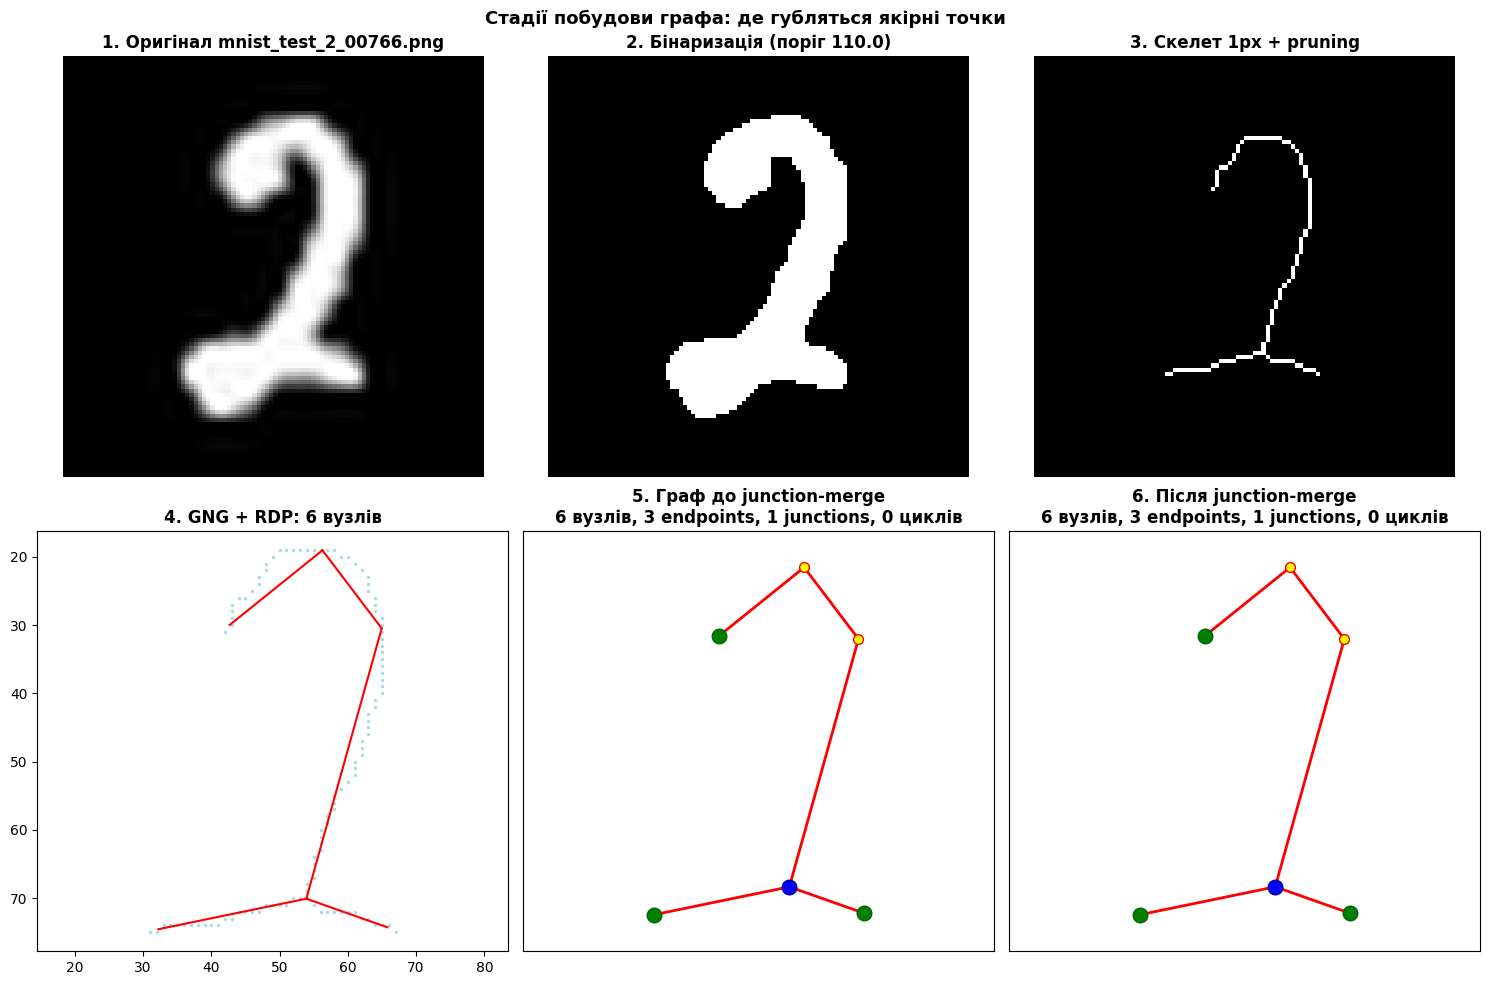

In [12]:
fig = pm.construction_figure(row, params)
report.save_figure(fig, "two_to_seven/mnist_test_2_00766_construction.png")

**1.6 Контрастний приклад** — `mnist_test_2_00984`: пласка курсивна «2», «чесно» схожа на 7 (не всі промахи — жертви скелетонізації).

saved researches/figures/two_to_seven/mnist_test_2_00984_triptych.png
saved researches/figures/two_to_seven/mnist_test_2_00984_construction.png


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/figures/two_to_seven/mnist_test_2_00984_construction.png')

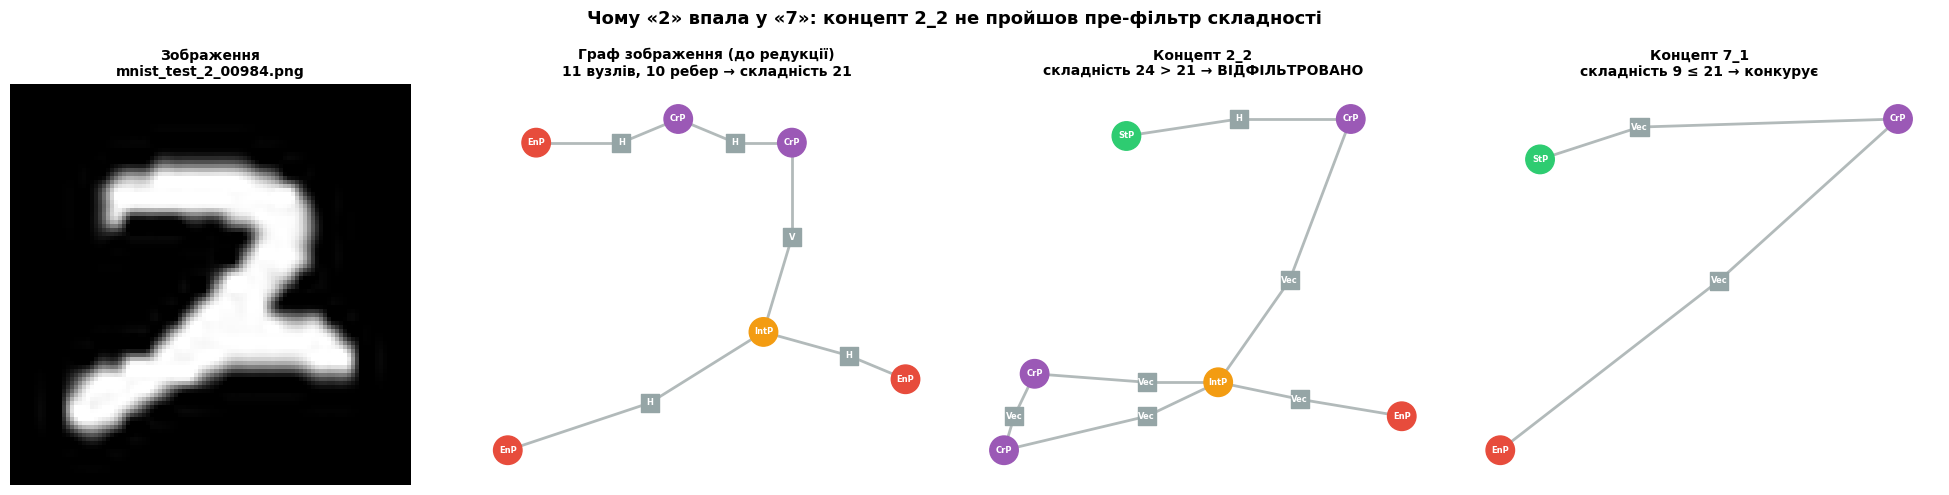

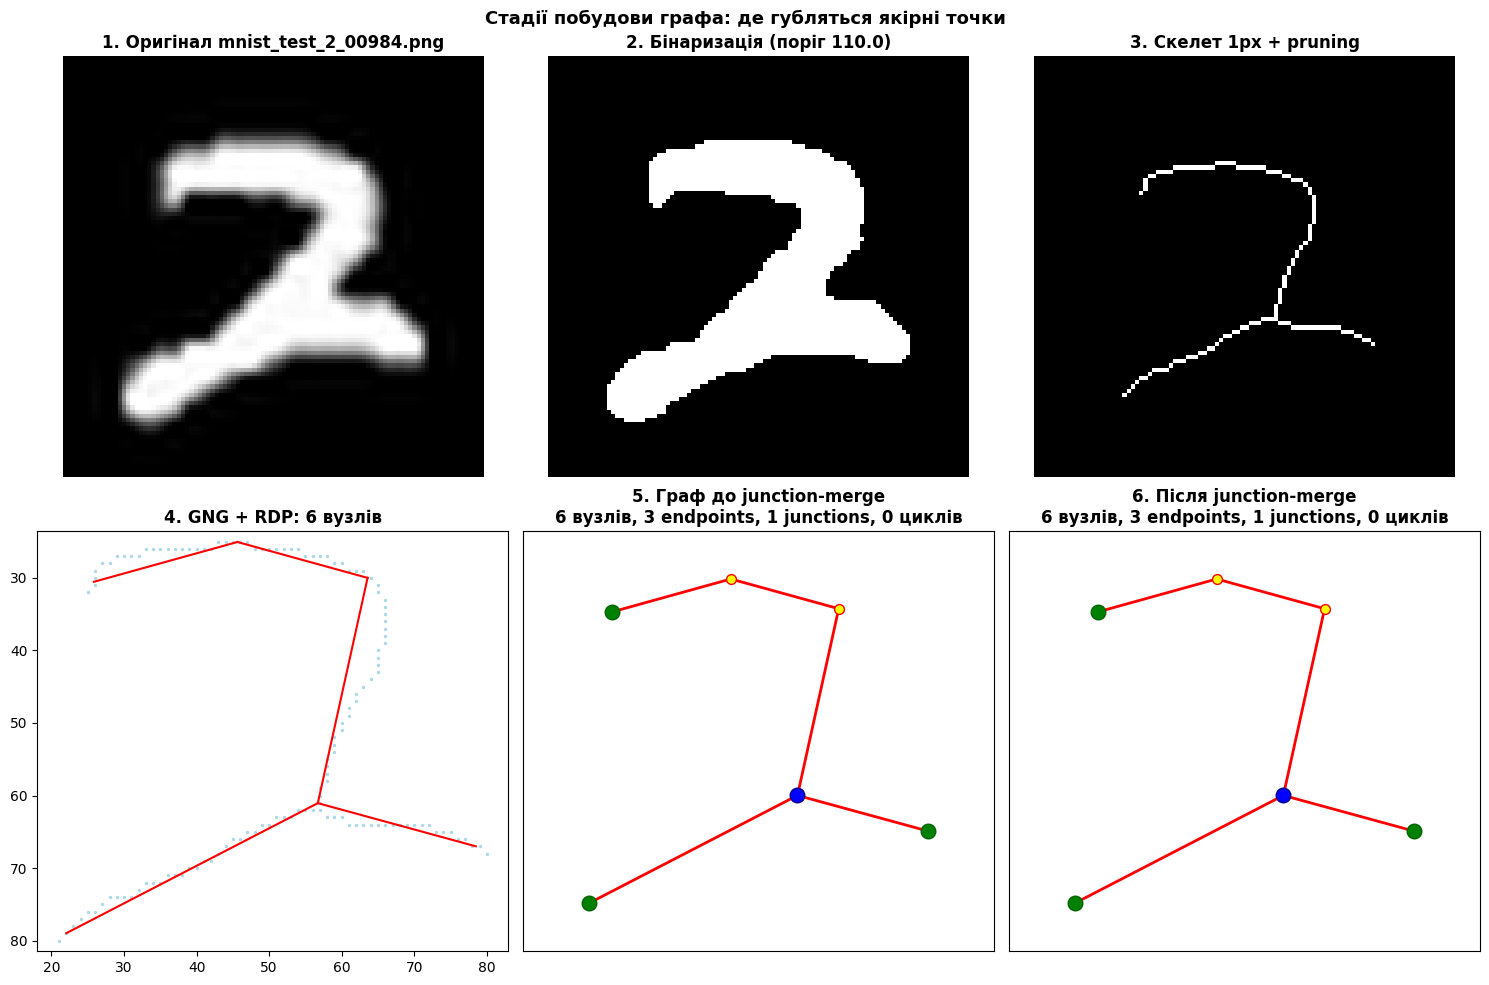

In [13]:
row_c = confusion[confusion.image_id == pm.CONTRAST_EXEMPLAR].iloc[0]
fig = pm.triptych(pm.CONTRAST_EXEMPLAR, row_c, concepts, params)
report.save_figure(fig, "two_to_seven/mnist_test_2_00984_triptych.png")
fig = pm.construction_figure(row_c, params)
report.save_figure(fig, "two_to_seven/mnist_test_2_00984_construction.png")

### Висновок (Секція 1)

- Складніший концепт «2» не програє WTA-конкуренцію — **він у неї не потрапляє**: пре-фільтр складності
  зрізає 2_2 у 86/111 випадків (77.5%), бо збіднений скелет має складність ≤ 21 < 24.
- Причина збіднення видима на фігурі стадій: **петля голови «2» руйнується на бінаризації/thinning**
  (0 циклів у скелеті), GNG+RDP довершують спрощення. Це і є «втрата якірних точок до редукції».
- Навіть уцілілий 2_1 програє 7_1 за сирою схожістю (розрив 0.14) — вцілілі точки геометрично зміщені
  (OUT-of-range за `distance_to_centroid`, `normalized_x`).
- λ-ранжування невинне: бакет C = 0. Головний важіль — **скелетонізація, що зберігає петлі**;
  пом'якшення пре-фільтра — лише симптоматичне (властивісне, без хардкоду concept_id).

Повний текст: `researches/two_to_seven_postmortem.md`.

## Секція 2 — Параметри концептів і компресія (S6)

### 2.0 Підготовка даних формування (спільна для Секцій 2–5)

Після успішного створення концепту сервіс **видаляє** session-графи навчальних зразків із Neo4j
(`critical_point_concept_service.py:168-172`), тож їх треба одноразово ре-інгестувати через пайплайн
(додатково, неруйнівно: ~875 зображень ≈ кілька хвилин). Потрібен живий пайплайн
(`make start_services` + Nuclio-функції; див. Секцію 0). Далі графи експортуються у JSON для
офлайн-проб — після цього Секції 2–5 працюють без Kafka/Nuclio.

⚠️ Навчальні вибірки **вже аугментовані**: файли `mnist_2_00006_aug1..aug10` + оригінал без суфікса.

In [14]:
from supervisor_experiments import formation_lab as fl
import pandas as pd
status = pd.DataFrame(fl.sessions_status()).T
display(status)
need_ingest = (status.graphs_in_neo4j < status.files_on_disk).any()
print("Треба інгестувати" if need_ingest else "✅ Session-графи вже у Neo4j")

,files_on_disk,graphs_in_neo4j
0_1,33,0
1_1,33,0
1_3,55,0
2_1,121,0
2_2,55,0
3_1,77,0
4_1,42,0
4_2,65,0
5_1,88,0
6_1,77,0


Треба інгестувати


In [15]:
# Одноразово: ре-інгест відсутніх session-графів (потрібен живий пайплайн!)
fl.ingest_missing_sessions()

  0_1: ingesting 33 samples ...
Running training script for prepared samples class 0 subclass 1... 
Sending data to connector... 


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   194  100    34  100   160    400   1884 --:--:-- --:--:-- --:--:--  2309


Images processed and sent to Kafka
Data sent to connector successfully. 
Training script completed. 
Monitoring topic 'contour-analysis-output-topic' for 10s of inactivity…
No messages for 5s…
No messages for 6s…
No messages for 7s…
No messages for 8s…
No messages for 9s…
Idle for 10s — done.
  1_1: ingesting 33 samples ...
Running training script for prepared samples class 1 subclass 1... 
Sending data to connector... 


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   194  100    34  100   160    863   4062 --:--:-- --:--:-- --:--:--  4974


Images processed and sent to Kafka
Data sent to connector successfully. 
Training script completed. 
Monitoring topic 'contour-analysis-output-topic' for 10s of inactivity…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Message

...

Images processed and sent to Kafka
Data sent to connector successfully. 
Training script completed. 
Monitoring topic 'contour-analysis-output-topic' for 10s of inactivity…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Message

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   194  100    34  100   160   1177   5539 --:--:-- --:--:-- --:--:--  6928


Images processed and sent to Kafka
Data sent to connector successfully. 
Training script completed. 
Monitoring topic 'contour-analysis-output-topic' for 10s of inactivity…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Message

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   194  100    34  100   160    599   2819 --:--:-- --:--:-- --:--:--  3464


Sending data to connector... 
Images processed and sent to Kafka
Data sent to connector successfully. 
Training script completed. 
Monitoring topic 'contour-analysis-output-topic' for 10s of inactivity…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received, resetting idle timer…
Messages received,

In [16]:
# Експорт session-графів у JSON (основа офлайн-проб Секцій 2–5)
for cid in fl.ALL_CONCEPTS:
    samples = fl.SAMPLES_ROOT / cid
    if not samples.exists() or not any(samples.glob("*.json")):
        fl.export_session_graphs(cid, samples)
print("✅ Експортовано")

exported 33/33 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/0_1


exported 33/33 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/1_1


exported 55/55 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/1_3


exported 121/121 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/2_1


exported 55/55 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/2_2


...

exported 88/88 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/5_1


exported 77/77 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/6_1


exported 99/99 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/7_1


exported 42/42 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/8_1


exported 88/88 graphs to /Users/mlapin/Development/personal/NaturalAGI/src/training/training_results/formation_samples/9_2
✅ Експортовано


### 2.1 Які параметри зберігають концепти і наскільки стискається їх первинна кількість

Конвенція підрахунку: range-властивість `{min, max, center}` = 2 збережені числа (center — похідний);
скаляр/рядок = 1; список = довжина; labels = кількість міток; службові властивості (id/session) не рахуються.

In [17]:
from supervisor_experiments import parameter_compression as pc, postmortem as pm, report
snapshot = pm.load_run_concepts()
table = pc.compression_table(snapshot)
display(table)
report.write_text("concept_parameter_compression.md",
    "# S6: Параметри концептів і компресія\n\n" + report.df_to_markdown(table, floatfmt=".1f") + "\n")

,concept_id,samples,input_nodes,input_edges,input_values,concept_nodes,concept_edges,concept_values,concept_ranges,topology_compression_x,value_compression_x
0,0_1,33,418,418,14550,10,10,628,289,41.8,23.2
1,1_1,33,235,202,7912,7,6,433,196,33.6,18.3
2,1_3,55,187,132,6187,3,2,179,82,62.3,34.6
3,2_1,121,1237,1116,42093,7,6,435,199,176.7,96.8
4,2_2,55,902,902,31536,12,12,759,350,75.2,41.5
5,3_1,77,1093,1016,37710,9,8,556,256,121.4,67.8
6,4_1,42,462,458,15949,8,8,506,233,57.8,31.5
7,4_2,65,631,566,21502,9,8,562,256,70.1,38.3
8,5_1,88,1192,1104,40641,7,6,435,199,170.3,93.4
9,6_1,77,1050,1050,37005,10,10,632,292,105.0,58.6


saved researches/concept_parameter_compression.md (17 lines)


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/concept_parameter_compression.md')

In [18]:
survival = pc.property_survival(snapshot)
display(survival)
kinds = pc.property_kinds(snapshot)
display(kinds.head(10))
with open(report.RESEARCHES / "concept_parameter_compression.md", "a") as f:
    f.write("\n## Виживання властивостей (частка вузлів, що несуть властивість)\n\n"
            + report.df_to_markdown(survival, floatfmt=".3f")
            + "\n\n## Типи властивостей за видом вузла\n\n"
            + report.df_to_markdown(kinds, floatfmt=".2f") + "\n")

,image_nodes_share,concept_nodes_share,survives
quadrant,1.000,1.000,True
quadrant_change_count,1.000,1.000,True
labels,1.000,1.000,True
is_concept,1.000,1.000,True
betweenness_centrality,1.000,1.000,True
intersection_points_count,1.000,1.000,True
normalized_x,1.000,1.000,True
normalized_y,1.000,1.000,True
closeness_centrality,1.000,1.000,True
pagerank,1.000,1.000,True


nodes  ranges_mean  scalars_mean  strings_mean  \
concept_id node_kind                                                   
0_1        Point          5        29.20           1.0          2.00   
           Vector         5        27.60           1.0          2.20   
1_1        Point          4        26.00           1.0          2.00   
           Vector         3        29.00           1.0          3.00   
1_3        Point          2        24.50           1.0          1.00   
           Vector         1        28.00           1.0          2.00   
2_1        Point          4        27.50           1.0          2.00   
           Vector         3        28.00           1.0          2.33   
2_2        Point          6        28.83           1.0          2.00   
           Vector         6        28.67           1.0          2.17   

                      values_mean  
concept_id node_kind               
0_1        Point            63.80  
           Vector           59.60  
1_1        Point            57.50  
           Vector           64.00  
1_3        Point            54.00  
           Vector           61.00  
2_1        Point            60.50  
           Vector           60.67  
2_2        Point            63.00  
           Vector           61.67

### Висновок (Секція 2)

Заповніть після запуску: скільки range-конвертів несе типовий вузол концепту (~27–29), сумарна
топологічна компресія (Σ вузлів входу / вузлів концепту) і компресія значень; які властивості
не виживають злиття (рядкові, що відрізняються між зразками → None; списки → перетин).

## Секція 3 — За скільки кроків редукції отримуємо сталий концепт (S5)

Два рівні відповіді: **внутрішній** — скільки ітерацій критично-точкової редукції
(endpoint → intersection → corner, ліміт 6, збіжність = ізоморфізм критичних графів) потребує кожне
злиття; **зовнішній** — після скількох зразків концепт перестає змінюватися (фікспойнт топології +
насичення конвертів). Проби виконуються офлайн продукційним кодом (~15–40 хв на всі 13 концептів).

In [19]:
from supervisor_experiments import convergence as cv
conv_df = cv.run_convergence_probes()
display(conv_df)

[probe 0_1] elapsed 4.2s
[probe 1_1] elapsed 2.1s
[probe 1_3] elapsed 2.0s
[probe 2_1] elapsed 3.2s
[probe 2_2] elapsed 3.1s
[probe 3_1] elapsed 3.0s
[probe 4_1] elapsed 2.0s
[probe 4_2] elapsed 2.6s
[probe 5_1] elapsed 3.0s
[probe 6_1] elapsed 3.1s
[probe 7_1] elapsed 2.6s
[probe 8_1] elapsed 2.7s
[probe 9_2] elapsed 3.2s


,concept_id,samples,final_nodes,final_edges,mean_xy_width,failed
0,0_1,33,10,10,0.7900,False
1,1_1,33,7,6,0.3786,False
2,1_3,55,3,2,0.5333,False
3,2_1,121,7,6,0.8286,False
4,2_2,55,12,12,0.4333,False
5,3_1,77,9,8,0.7111,False
6,4_1,12,0,0,0.5406,True
7,4_2,65,9,8,0.4667,False
8,5_1,88,7,6,0.9000,False
9,6_1,77,10,10,0.8025,False


saved researches/figures/convergence/trajectories.png


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/figures/convergence/trajectories.png')

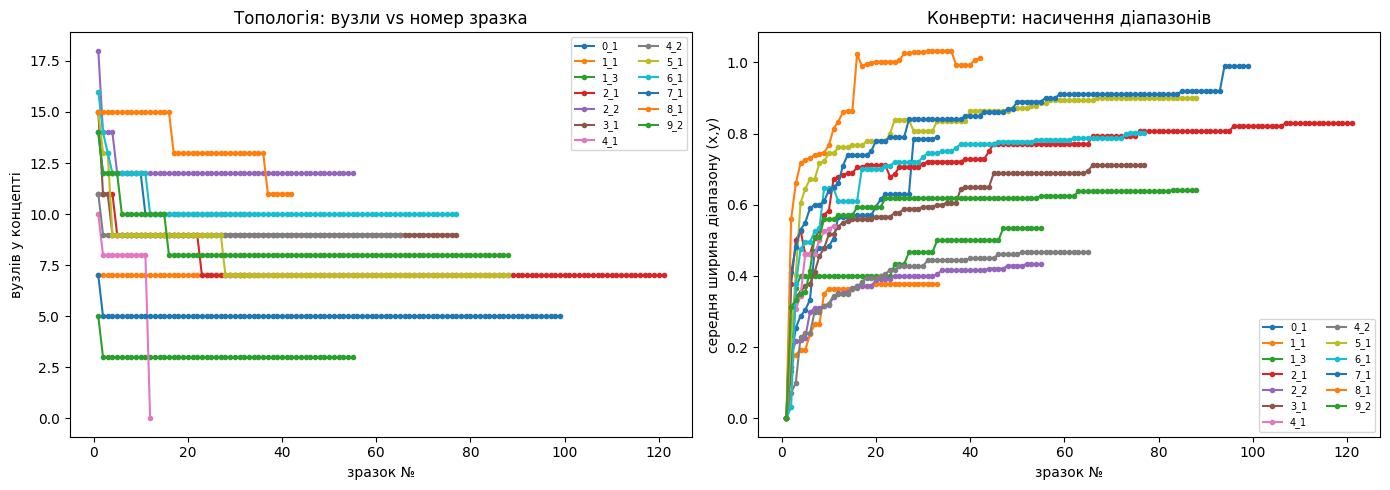

In [20]:
fig = cv.plot_trajectories()
report.save_figure(fig, "convergence/trajectories.png")

,concept_id,m_topology,m_envelope,total_samples
0,0_1,11,13,33
1,1_1,1,10,33
2,1_3,2,5,55
3,2_1,23,12,121
4,2_2,5,12,55
5,3_1,4,13,77
6,4_1,12,11,12
7,4_2,2,12,65
8,5_1,28,11,88
9,6_1,12,18,77


saved researches/figures/convergence/cpp_iterations_hist.png
saved researches/concept_convergence_findings.md (21 lines)


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/concept_convergence_findings.md')

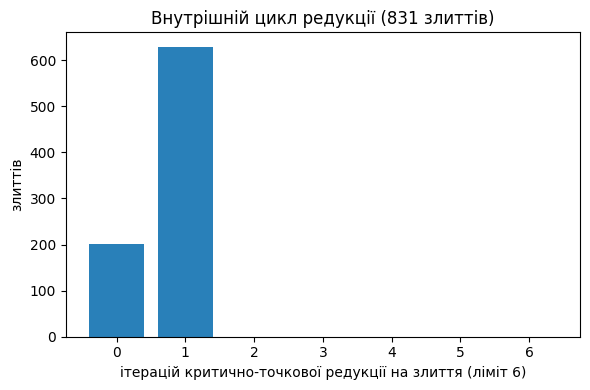

In [21]:
stab = cv.stability_table()
display(stab)
fig = cv.plot_cpp_histogram()
report.save_figure(fig, "convergence/cpp_iterations_hist.png")
report.write_text("concept_convergence_findings.md",
    "# S5: Збіжність редукції\n\n## Сталість концепту (номер зразка m)\n\n"
    + report.df_to_markdown(stab, floatfmt=".0f")
    + "\n\n![Траєкторії](figures/convergence/trajectories.png)\n"
    + "![Ітерації](figures/convergence/cpp_iterations_hist.png)\n")

### Висновок (Секція 3)

Заповніть: типове m_topology (коли фіксується топологія) проти m_envelope (коли насичуються
діапазони) та розподіл внутрішніх ітерацій (скільки злиттів обходяться 0–1 ітерацією, скільки
впираються в ліміт 6 — маркер топологічної гетерогенності, як у 8_1).

## Секція 4 — Чи залежить концепт від послідовності пред'явлення (S2)

Відповідь на рівні коду — **так**: перший зразок стає зародком концепту
(`critical_point_concept_service.py:87-88`), а історично порядок вибірки з Neo4j був
недетермінованим (запит без `ORDER BY` + паралельний Kafka-інгест) — виправлено в цій гілці
(`ORDER BY image_id`). Тут вимірюємо, наскільки сильно порядок змінює результат: 10 сідів × 3
концепти (2_2 — середній, 7_1 — найменший, 8_1 — схильний до крешів на гетерогенній топології).

In [22]:
from supervisor_experiments import order_dependence as od
order_df = od.run_order_probes()
display(order_df)

[probe 2_2 seed=0] elapsed 3.1s
[probe 2_2 seed=1] elapsed 3.1s
[probe 2_2 seed=2] elapsed 3.0s
[probe 2_2 seed=3] elapsed 3.0s
[probe 2_2 seed=4] elapsed 3.2s
[probe 2_2 seed=5] elapsed 3.1s
[probe 2_2 seed=6] elapsed 3.1s
[probe 2_2 seed=7] elapsed 3.1s
[probe 2_2 seed=8] elapsed 3.1s
[probe 2_2 seed=9] elapsed 3.1s
[probe 7_1 seed=0] elapsed 2.5s
[probe 7_1 seed=1] elapsed 2.5s
[probe 7_1 seed=2] elapsed 2.4s
[probe 7_1 seed=3] elapsed 2.5s
[probe 7_1 seed=4] elapsed 2.5s
[probe 7_1 seed=5] elapsed 2.6s
[probe 7_1 seed=6] elapsed 2.5s
[probe 7_1 seed=7] elapsed 2.5s
[probe 7_1 seed=8] elapsed 2.5s
[probe 7_1 seed=9] elapsed 2.4s
[probe 8_1 seed=0] elapsed 2.8s
[probe 8_1 seed=1] elapsed 2.7s
[probe 8_1 seed=2] elapsed 2.8s
[probe 8_1 seed=3] elapsed 2.8s
[probe 8_1 seed=4] elapsed 2.7s
[probe 8_1 seed=5] elapsed 2.8s
[probe 8_1 seed=6] elapsed 2.8s
[probe 8_1 seed=7] elapsed 2.9s
[probe 8_1 seed=8] elapsed 2.8s
[probe 8_1 seed=9] elapsed 2.8s


,concept_id,seed,final_nodes,final_edges,mean_xy_width,failed
0,2_2,0,12,12,0.4583,False
1,2_2,1,12,12,0.4500,False
2,2_2,2,12,12,0.4500,False
3,2_2,3,12,12,0.4500,False
4,2_2,4,12,12,0.4417,False
5,2_2,5,12,12,0.4500,False
6,2_2,6,12,12,0.4375,False
7,2_2,7,12,12,0.4500,False
8,2_2,8,12,12,0.4917,False
9,2_2,9,12,12,0.4500,False


In [23]:
ged_matrices = {}
for cid in od.DEFAULT_CONCEPTS:
    ged_matrices[cid] = od.pairwise_ged(cid)
    print(f"— {cid}:")
    display(ged_matrices[cid])
summary = od.summarize(order_df, ged_matrices)
display(summary)
report.write_text("order_dependence_findings.md",
    "# S2: Залежність від порядку пред'явлення\n\n"
    "Кодовий факт: перший зразок = зародок; порядок з Neo4j був недетермінований до ORDER BY-фіксу.\n\n"
    + report.df_to_markdown(summary, floatfmt=".2f") + "\n")

— 2_2:


,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
5,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


— 7_1:


,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


— 8_1:


,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,concept_id,seeds,failures,node_counts,identical_topology_share,mean_pairwise_ged,max_pairwise_ged,width_min,width_max
0,2_2,10,0,[12],0.64,0.36,1.0,0.438,0.492
1,7_1,10,0,[5],1.00,0.00,0.0,0.870,1.010
2,8_1,10,0,[11],1.00,0.00,0.0,0.766,1.066


saved researches/order_dependence_findings.md (8 lines)


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/order_dependence_findings.md')

### Висновок (Секція 4)

Заповніть: частка пар сідів з ідентичною топологією, середній/максимальний попарний GED,
частота крешів формування (особливо 8_1). Якщо розкид ненульовий — рекомендація: канонічний
порядок (вже увімкнений ORDER BY) або відбір найкращого сіда за офлайн-метрикою ширини конвертів.

## Секція 5 — Як залежить побудова концепту від кількості прикладів (S3, офлайн)

Формування на підвибірках N ∈ {2, 5, 10, 20} × 3 сіди для всіх 13 концептів (~156 проб, ~30–60 хв;
звузьте `CONCEPTS_S3`, якщо треба швидше). ⚠️ Файли вибірки корельовані (10 аугментацій на джерело),
тож «ефективна» кількість незалежних прикладів ≈ N/10 — врахуйте в інтерпретації.
Downstream-точність для обраних N — у Секції 7 (потрібен ретрен).

In [24]:
from supervisor_experiments import sample_count as sc
CONCEPTS_S3 = sc.ALL_CONCEPTS  # звузьте за потреби, напр. ["2_2", "7_1", "8_1", "3_1"]
sc_df = sc.run_sample_count_grid(CONCEPTS_S3)
display(sc.aggregate(sc_df))

[probe 0_1 N=2 seed=0] elapsed 1.9s
[probe 0_1 N=2 seed=1] elapsed 1.9s
[probe 0_1 N=2 seed=2] elapsed 2.1s
[probe 0_1 N=5 seed=0] elapsed 1.9s
[probe 0_1 N=5 seed=1] elapsed 1.9s
[probe 0_1 N=5 seed=2] elapsed 2.1s
[probe 0_1 N=10 seed=0] elapsed 2.0s
[probe 0_1 N=10 seed=1] elapsed 2.0s
[probe 0_1 N=10 seed=2] elapsed 2.2s
[probe 0_1 N=20 seed=0] elapsed 4.9s
[probe 0_1 N=20 seed=1] elapsed 2.4s
[probe 0_1 N=20 seed=2] elapsed 2.6s
[probe 1_1 N=2 seed=0] elapsed 2.0s
[probe 1_1 N=2 seed=1] elapsed 2.0s
[probe 1_1 N=2 seed=2] elapsed 2.0s
[probe 1_1 N=5 seed=0] elapsed 1.9s
[probe 1_1 N=5 seed=1] elapsed 2.1s
[probe 1_1 N=5 seed=2] elapsed 2.1s
[probe 1_1 N=10 seed=0] elapsed 1.8s
[probe 1_1 N=10 seed=1] elapsed 1.9s
[probe 1_1 N=10 seed=2] elapsed 1.9s
[probe 1_1 N=20 seed=0] elapsed 2.0s
[probe 1_1 N=20 seed=1] elapsed 2.3s
[probe 1_1 N=20 seed=2] elapsed 2.2s
[probe 1_3 N=2 seed=0] elapsed 2.0s
[probe 1_3 N=2 seed=1] elapsed 1.9s
[probe 1_3 N=2 seed=2] elapsed 1.9s
[probe 1_3 N=5 s

,concept_id,n_samples,nodes_mean,nodes_std,width_mean,runs
0,0_1,2,12.000,0.000,0.185,3
1,0_1,5,10.667,1.155,0.407,3
2,0_1,10,10.000,0.000,0.527,3
3,0_1,20,10.000,0.000,0.633,3
4,1_1,2,7.000,0.000,0.190,3
5,1_1,5,7.000,0.000,0.290,3
6,1_1,10,7.000,0.000,0.319,3
7,1_1,20,7.000,0.000,0.367,3
8,1_3,2,3.667,1.155,0.129,3
9,1_3,5,3.000,0.000,0.322,3


saved researches/figures/sample_count/curves.png


n_samples,2,5,10,20
concept_id,,,,
0_1,0.0,0.0,0.0,0.0
1_1,0.0,0.0,0.0,0.0
1_3,0.0,0.0,0.0,0.0
2_1,0.0,0.0,0.0,0.0
2_2,0.0,0.0,0.0,0.0
3_1,0.0,0.0,0.0,0.0
4_1,0.0,67.0,100.0,100.0
4_2,0.0,0.0,0.0,0.0
5_1,0.0,0.0,0.0,0.0


saved researches/sample_count_findings.md (76 lines)


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/sample_count_findings.md')

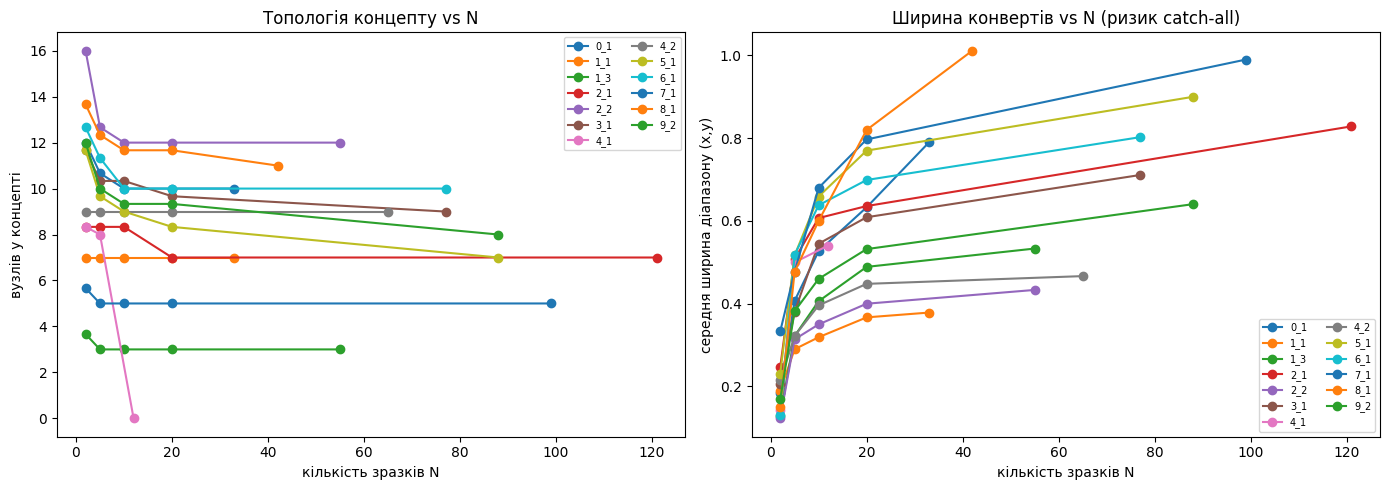

In [25]:
fig = sc.plot_curves(sc_df, full_reference=conv_df if "conv_df" in dir() else None)
report.save_figure(fig, "sample_count/curves.png")
display(sc.failure_table(sc_df))
report.write_text("sample_count_findings.md",
    "# S3: Залежність від кількості прикладів (офлайн-частина)\n\n"
    + report.df_to_markdown(sc.aggregate(sc_df), floatfmt=".2f")
    + "\n\n![Криві](figures/sample_count/curves.png)\n"
    + "\n\n## Частка крешів формування, %\n\n"
    + report.df_to_markdown(sc.failure_table(sc_df), floatfmt=".0f")
    + "\n\n(Downstream-точність — див. Секцію 7 і augmentation_findings.md)\n")

### Висновок (Секція 5)

Заповніть: чи стабілізується топологія вже на малих N (порівняйте з m_topology Секції 3), як росте
ширина конвертів зі збільшенням N (ризик catch-all), чи є N, після якого додаткові зразки лише
розширюють діапазони без зміни структури.

## Секція 6 — Інші датасети MNIST (S1)

Потрібен живий пайплайн. Прогони (базлайн-параметри, `fraction=1.0`):
1. **10k тест без виключень** (~1–2 год) — додає ~1 296 incomplete-зображень;
2. **60k train-спліт**: без виключень і complete-only (~7–14 год кожен, `delete_image_nodes=true`);
3. **70k** = агрегація прогонів 1+2 (окремий прогін не потрібен).

Розмітка повноти для 60k — евристична (`scripts/completeness_heuristic.py`, без ручної перевірки —
зазначайте як caveat). Каталог `datasets/mnist_train_all/` будується один раз (~10–20 хв).

In [26]:
from supervisor_experiments import dataset_variants as dv
display(dv.manifest_counts(dv.TEST_MANIFEST))

structure,complete,incomplete,unreviewed,total
class,,,,
0,828,151,1,980
1,1128,7,0,1135
2,956,76,0,1032
3,969,41,0,1010
4,953,29,0,982
5,796,96,0,892
6,742,216,0,958
7,1014,14,0,1028
8,582,392,0,974


In [27]:
# Побудова 60k-каталогу (одноразово, ~10–20 хв; idempotent)
import subprocess, sys
if not dv.TRAIN_MANIFEST.exists() or sum(1 for _ in open(dv.TRAIN_MANIFEST)) < 60000:
    proc = subprocess.run([sys.executable, str(dv.REPO / "scripts" / "build_mnist_train_dataset.py")],
                          cwd=dv.REPO, text=True)
    print("exit:", proc.returncode)
display(dv.manifest_counts(dv.TRAIN_MANIFEST))

Building 60000 images -> /Users/mlapin/Development/personal/NaturalAGI/datasets/mnist_train_all (100x100)
  5000/60000 (4s)
  10000/60000 (7s)
  15000/60000 (10s)
  20000/60000 (13s)
  25000/60000 (16s)
  30000/60000 (19s)
  35000/60000 (22s)
  40000/60000 (26s)
  45000/60000 (29s)
  50000/60000 (32s)
  55000/60000 (35s)
  60000/60000 (38s)
Done: 60000 images, complete=45501 (75.8%), manifest -> /Users/mlapin/Development/personal/NaturalAGI/datasets/mnist_train_all_manifest.csv
exit: 0


structure,complete,incomplete,total
class,,,
0,4942,981,5923
1,6422,320,6742
2,4675,1283,5958
3,4354,1777,6131
4,4993,849,5842
5,3492,1929,5421
6,4457,1461,5918
7,5424,841,6265
8,2515,3336,5851


In [28]:
for exp in dv.s1_experiments():
    dv.ensure_experiment(exp)

exp_s1_test10k_unfiltered: додано до черги
exp_s1_train60k_unfiltered: додано до черги
exp_s1_train60k_complete: додано до черги


In [29]:
# ДОВГА КЛІТИНКА (~1–2 год): 10k тест без виключень
dv.run_experiment("exp_s1_test10k_unfiltered", fraction=1.0)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL () { ... }', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nCALL {\n    MATCH (n:Point {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:Vector {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:StartPoint {concept_id: $concept_id}) RETURN n\n}\nWITH n, labels(n) AS node_labels, properties(n) as node_props\nOPTIONAL MATCH (n)-[r]-(m {concept_id: $concept_id})\nWITH n, node_

In [30]:
run10k = dv.load_queue()
exp = next(e for e in run10k["experiments"] if e["id"] == "exp_s1_test10k_unfiltered")
RUN_10K = exp["quick_run_id"] if exp["full_run_id"] is None else exp["full_run_id"]
split10k = dv.split_metrics(RUN_10K, dv.TEST_MANIFEST)
display(split10k)  # порівняйте complete-рядок із базлайном 91.13%

,structure,submitted,wrong,accuracy_%
0,complete,8704,793,90.89
1,incomplete,1295,985,23.94
2,unreviewed,1,1,0.00
3,ALL,10000,1779,82.21


In [31]:
# ДУЖЕ ДОВГІ КЛІТИНКИ (~7–14 год кожна): 60k train-спліт
dv.run_experiment("exp_s1_train60k_unfiltered", fraction=1.0)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL () { ... }', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nCALL {\n    MATCH (n:Point {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:Vector {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:StartPoint {concept_id: $concept_id}) RETURN n\n}\nWITH n, labels(n) AS node_labels, properties(n) as node_props\nOPTIONAL MATCH (n)-[r]-(m {concept_id: $concept_id})\nWITH n, node_

In [32]:
dv.run_experiment("exp_s1_train60k_complete", fraction=1.0)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL () { ... }', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nCALL {\n    MATCH (n:Point {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:Vector {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:StartPoint {concept_id: $concept_id}) RETURN n\n}\nWITH n, labels(n) AS node_labels, properties(n) as node_props\nOPTIONAL MATCH (n)-[r]-(m {concept_id: $concept_id})\nWITH n, node_

In [33]:
q = dv.load_queue()
def _run_of(eid):
    e = next(x for x in q["experiments"] if x["id"] == eid)
    return e["full_run_id"] or e["quick_run_id"]
RUN_60K_ALL = _run_of("exp_s1_train60k_unfiltered")
rows = [("10k тест", RUN_10K, dv.TEST_MANIFEST), ("60k train", RUN_60K_ALL, dv.TRAIN_MANIFEST)]
frames = []
for label, rid, manifest in rows:
    df = dv.split_metrics(rid, manifest); df["dataset"] = label; frames.append(df)
import pandas as pd
split_all = pd.concat(frames, ignore_index=True)
agg70k = dv.aggregate_runs([(RUN_10K, dv.TEST_MANIFEST), (RUN_60K_ALL, dv.TRAIN_MANIFEST)])
display(split_all); display(agg70k.tail(3))
report.write_text("dataset_variants_findings.md",
    "# S1: Класифікація на інших датасетах MNIST\n\n"
    "Якір: complete-only 10k = 91.13% (run_20260630_235356).\n\n"
    + report.df_to_markdown(split_all, floatfmt=".2f")
    + "\n\n## 70k (агрегація 10k+60k)\n\n"
    + report.df_to_markdown(agg70k.tail(3), floatfmt=".2f")
    + "\n\nCaveats: 60k розмічено евристикою; ~875 навчальних зразків походять із train-спліту (leakage ≤1.5%).\n")

,structure,submitted,wrong,accuracy_%,dataset
0,complete,8704,793,90.89,10k тест
1,incomplete,1295,985,23.94,10k тест
2,unreviewed,1,1,0.00,10k тест
3,ALL,10000,1779,82.21,10k тест
4,complete,45501,10867,76.12,60k train
5,incomplete,14499,5961,58.89,60k train
6,ALL,60000,16828,71.95,60k train


,structure,submitted,wrong,accuracy_%,run_id
5,incomplete,14499,5961,58.89,run_20260717_162928
6,ALL,60000,16828,71.95,run_20260717_162928
7,ALL (агреговано),70000,18607,73.42,run_20260717_161201+run_20260717_162928


saved researches/dataset_variants_findings.md (21 lines)


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/dataset_variants_findings.md')

### Висновок (Секція 6)

Заповніть: наскільки падає точність на incomplete-підмножині (очікувано різко: розірвані контури →
збіднені графи → малі концепти-атрактори + DLQ), чи тримається complete-точність на 60k
(генералізація на новий спліт), підсумкові числа для 10k/60k/70k у обох режимах.

## Секція 7 — 🔴 Ретрени: кількість прикладів downstream (S3) і аугментація (S4)

**Руйнівно**: кожен ретрен замінює концепти в Neo4j. Правила: (1) бекап із Секції 0 обов'язковий;
(2) після серії умов — відновлення базлайну; (3) QUICK 25% для сканів, повний прогін лише для
фіналістів (`baseline_accuracy` в queue.json — тільки з повних прогонів).

Вибірки вже аугментовані (~10 варіацій + оригінал на джерело), тому умови S4 будуються
підмножинами наявних файлів: `aug0` = лише оригінали (без аугментації), `aug3` = оригінал+3,
`baseline` = всі, `aug2x` = всі + нові варіації (`scripts/augment_train.py`: поворот ±12°,
масштаб 0.85–1.15, еластика, товщина штриха).

In [34]:
from supervisor_experiments import tier_c
tier_c.ensure_backup()
baseline_nodes = tier_c.concept_node_counts()
print("Базлайн-вузли:", baseline_nodes)

RuntimeError: Немає бекапа /Users/mlapin/Development/personal/NaturalAGI/backups/neo4j_baseline_2026-07-17.tar.gz — виконайте клітинку бекапа в Секції 0 перед будь-якими ретренами.

In [36]:
# Умовні набори (копії у datasets/train_subsets/<умова>/)
tier_c.build_condition_dirs("N5_seed0", tier_c.subset_n(5, 0))
tier_c.build_condition_dirs("N20_seed0", tier_c.subset_n(20, 0))
tier_c.build_condition_dirs("aug0", tier_c.aug_cap(0))
tier_c.build_condition_dirs("aug3", tier_c.aug_cap(3))

N5_seed0: 65 файлів — {'0_1': 5, '1_1': 5, '1_3': 5, '2_1': 5, '2_2': 5, '3_1': 5, '4_1': 5, '4_2': 5, '5_1': 5, '6_1': 5, '7_1': 5, '8_1': 5, '9_2': 5}
N20_seed0: 260 файлів — {'0_1': 20, '1_1': 20, '1_3': 20, '2_1': 20, '2_2': 20, '3_1': 20, '4_1': 20, '4_2': 20, '5_1': 20, '6_1': 20, '7_1': 20, '8_1': 20, '9_2': 20}
aug0: 86 файлів — {'0_1': 3, '1_1': 3, '1_3': 5, '2_1': 11, '2_2': 5, '3_1': 7, '4_1': 7, '4_2': 6, '5_1': 8, '6_1': 7, '7_1': 9, '8_1': 7, '9_2': 8}
aug3: 343 файлів — {'0_1': 12, '1_1': 12, '1_3': 20, '2_1': 44, '2_2': 20, '3_1': 28, '4_1': 28, '4_2': 23, '5_1': 32, '6_1': 28, '7_1': 36, '8_1': 28, '9_2': 32}


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/datasets/train_subsets/aug3')

In [37]:
# Нові аугментації поверх наявних (aug2x)
import subprocess, sys
subprocess.run([sys.executable, str(tier_c.REPO / "scripts" / "augment_train.py"),
                "--dst", str(tier_c.SUBSETS_ROOT / "aug2x"), "--per-image", "1"],
               cwd=tier_c.REPO, check=True)

0_1: 33 копій + 3 нових
1_1: 33 копій + 3 нових
1_3: 55 копій + 5 нових
2_1: 121 копій + 11 нових
2_2: 55 копій + 5 нових
3_1: 77 копій + 7 нових
4_1: 42 копій + 7 нових
4_2: 65 копій + 6 нових
5_1: 88 копій + 8 нових
6_1: 77 копій + 7 нових
7_1: 99 копій + 9 нових
8_1: 42 копій + 7 нових
9_2: 88 копій + 8 нових


CompletedProcess(args=['/Users/mlapin/Development/personal/NaturalAGI/natural-agi/bin/python', '/Users/mlapin/Development/personal/NaturalAGI/scripts/augment_train.py', '--dst', '/Users/mlapin/Development/personal/NaturalAGI/datasets/train_subsets/aug2x', '--per-image', '1'], returncode=0)

In [1]:
# 🔴 РЕТРЕН ОДНІЄЇ УМОВИ + QUICK-оцінка. Повторіть для кожної умови по черзі.
CONDITION = "aug0"          # ← N5_seed0 | N20_seed0 | aug0 | aug3 | aug2x
CONFIRM = "yes"              # ← "yes" щоб виконати ретрен

if CONFIRM == "yes":
    result = tier_c.retrain_from(tier_c.SUBSETS_ROOT / CONDITION, confirm=CONFIRM)
    display(result)
    print("Δ вузлів vs базлайн:",
          {c: tier_c.concept_node_counts().get(c, 0) - n for c, n in baseline_nodes.items()})
    from supervisor_experiments import dataset_variants as dv
    exp_id = f"exp_s34_{CONDITION}"
    dv.ensure_experiment({
        "id": exp_id, "name": f"s34_{CONDITION}",
        "description": f"S3/S4 умова {CONDITION} (QUICK 25%)",
        "classes": list(range(10)), "params": dv.baseline_params(),
    })
    dv.run_experiment(exp_id, fraction=0.25)
else:
    print('Поставте CONFIRM = "yes" і оберіть CONDITION.')

NameError: name 'tier_c' is not defined

In [39]:
# 🔴 ВІДНОВЛЕННЯ БАЗЛАЙНУ після серії умов
CONFIRM_RESTORE = "no"      # ← "yes" щоб відновити

if CONFIRM_RESTORE == "yes":
    tier_c.restore_baseline(CONFIRM_RESTORE)
    from supervisor_experiments import infra
    print(infra.health_check())
else:
    print('Поставте CONFIRM_RESTORE = "yes".')

Поставте CONFIRM_RESTORE = "yes".


In [40]:
# Зведення умов S3/S4 (після QUICK-прогонів)
q = dv.load_queue()
rows = [{"умова": e["id"].replace("exp_s34_", ""), "quick_accuracy": e["quick_accuracy"]}
        for e in q["experiments"] if e["id"].startswith("exp_s34_")]
import pandas as pd
s34 = pd.DataFrame(rows)
display(s34)
report.write_text("augmentation_findings.md",
    "# S3 (downstream) / S4: ретрени за умовами\n\n"
    "QUICK 25% — лише для порівняння між умовами (не базлайн).\n\n"
    + report.df_to_markdown(s34, floatfmt=".2f") + "\n")

""


saved researches/augmentation_findings.md (7 lines)


PosixPath('/Users/mlapin/Development/personal/NaturalAGI/researches/augmentation_findings.md')

### Висновок (Секція 7)

Заповніть: як точність залежить від N (5/20/всі) і від фактора аугментації (0/3/10/10+нові);
частота крешів формування за умовами (гетерогенність топології зростає з аугментацією);
чи виправдана поточна 10× аугментація проти помірної.

## Секція 8 — Зведений звіт для зустрічі

In [41]:
report.write_program_summary()
print(open(report.RESEARCHES / "supervisor_program_summary.md").read())

saved researches/supervisor_program_summary.md (13 lines)
# Зведення дослідницької програми (базлайн 91.13%, run_20260630_235356)

Артефакти по пунктах керівника:

- **1. Post-mortem 2→7** — [two_to_seven_postmortem.md](two_to_seven_postmortem.md) ✅
- **2. Параметри концептів і компресія (S6)** — [concept_parameter_compression.md](concept_parameter_compression.md) ✅
- **3. Збіжність редукції (S5)** — [concept_convergence_findings.md](concept_convergence_findings.md) ✅
- **4. Залежність від порядку (S2)** — [order_dependence_findings.md](order_dependence_findings.md) ✅
- **5. Залежність від кількості прикладів (S3)** — [sample_count_findings.md](sample_count_findings.md) ✅
- **6. Варіанти датасетів MNIST (S1)** — [dataset_variants_findings.md](dataset_variants_findings.md) ✅
- **7. Аугментація (S4)** — [augmentation_findings.md](augmentation_findings.md) ✅

Фігури: `researches/figures/`. Відтворення: `src/training/supervisor_experiments.ipynb` (kernel natural-agi).

